In [1]:
!pip install -q pytorch_fid torchmetrics torch-fidelity mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.0/684.0 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from math import log2
from PIL import Image
import torch 
from tqdm import tqdm
import shutil
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.utils as vutils

import mlflow
import mlflow.pytorch

from pytorch_fid import fid_score
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

from torchvision.utils import make_grid
from torchvision.transforms import RandomRotation, ColorJitter, RandomResizedCrop
from torchvision.transforms import Compose, Normalize, ToTensor, Resize, RandomHorizontalFlip
from torchvision.datasets import ImageFolder
import torch.nn.functional as F
import torch.quantization as quantization
from torch.nn.utils import spectral_norm
from torch.nn import TripletMarginLoss
from torchvision.models import *
from sklearn.model_selection import train_test_split

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure

In [3]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)
        if self.transform:
            image = self.transform(image)
        return image
    

In [4]:
def get_dataloader(data_paths : str, image_size : int, max_image_size : int = 128, batch_size : int = 64 , transform = None) :
    image_size = min(image_size, max_image_size)
    if transform is None:
        transform = Compose([
            ToTensor(),
            Resize((image_size,image_size)),
            RandomHorizontalFlip(0.5),
            Normalize(mean=[0.5, 0.5, 0.5],
                                std=[0.5, 0.5, 0.5])
        ])
    dataset = ImageDataset(image_paths = data_paths, transform= transform)
    return DataLoader(dataset, batch_size = batch_size, shuffle = True, drop_last=True)

In [5]:
path = "/kaggle/input/cats"

In [6]:
# train_paths = glob("/kaggle/input/animal-faces/afhq/train/cat/*.jpg")
# val_paths = glob("/kaggle/input/animal-faces/afhq/val/cat/*.jpg")

In [7]:
paths = glob(os.path.join(path,"*.jpg"))
train_paths , val_paths = train_test_split(paths, test_size=0.2)

In [8]:
train_dataloader = get_dataloader(train_paths, 128)

In [9]:
val_dataloader = get_dataloader(val_paths, 128)

In [10]:
transform = Compose([
    Resize((128, 128)),
    RandomHorizontalFlip(p=0.5),  # Lật ngang
    RandomRotation(degrees=10),   # Xoay 10 độ
    ColorJitter(brightness=0.2, contrast=0.2), 
    RandomResizedCrop(128, scale=(0.8, 1.0)),  
    ToTensor(), 
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

feature_extract_dataloader = get_dataloader(train_paths, 128 , transform=transform)

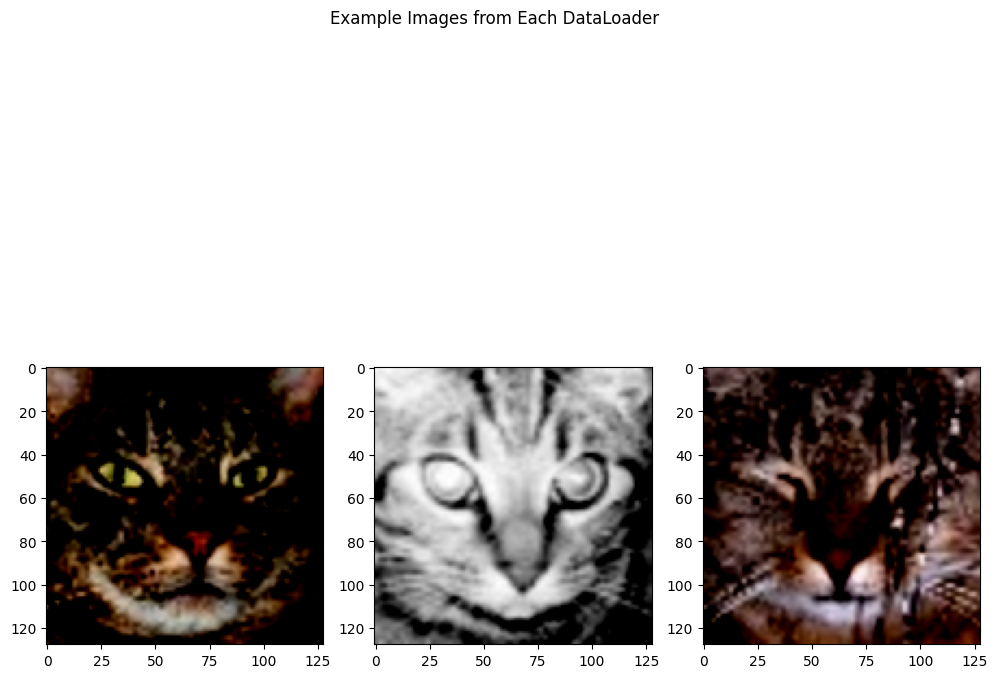

In [11]:
_ , ax = plt.subplots(1, 3, figsize=(10, 10))
batch = next(iter(train_dataloader))
first_image, seconds_image, thirds_image = batch[0], batch[1], batch[2]

first_image = np.transpose(first_image, (1, 2, 0))
seconds_image = np.transpose(seconds_image, (1, 2, 0))
thirds_image = np.transpose(thirds_image, (1, 2, 0))

ax[0].imshow(first_image)
ax[1].imshow(seconds_image)
ax[2].imshow(thirds_image)
plt.suptitle("Example Images from Each DataLoader")
plt.tight_layout()
plt.show()

In [12]:
def weights_init(m):
    classname = m.__class__.__name__
    
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02) 
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    
    # Khởi tạo cho BatchNorm2d
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, mean=1.0, std=0.02)  
        nn.init.constant_(m.bias.data, 0) 

In [13]:
class DiffusionProcess(nn.Module):
    def __init__(self, T, beta_start, beta_end , sigma=0.05):
        super(DiffusionProcess, self).__init__()
        self.T = 500
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1 - self.betas 
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.alpha_bars = self.alpha_bars.to(device)
        self.sigma = sigma

    def forward(self, x, t):
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1)
        noise = torch.randn_like(x) * self.sigma 
        noisy_x = torch.sqrt(alpha_bar_t) * x + torch.sqrt(1 - alpha_bar_t) * noise
        return noisy_x, noise

In [14]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim//8, 1)
        self.key = nn.Conv2d(in_dim, in_dim//8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, H, W = x.shape
        q = self.query(x).view(batch_size, -1, H*W).permute(0, 2, 1) # (B, N, C')
        k = self.key(x).view(batch_size, -1, H*W) # (B, C', N)
        v = self.value(x).view(batch_size, -1, H*W) # (B, C, N)

        attention = torch.bmm(q, k) # (B, N, N)
        attention = torch.softmax(attention, dim=-1)

        out = torch.bmm(v, attention.permute(0, 2, 1)) # (B, C, N)
        out = out.view(batch_size, C, H, W)
        return self.gamma * out + x

In [15]:
# class Discriminator(nn.Module):
#     def __init__(self):
#         super(Discriminator, self).__init__()
#         self.main = nn.Sequential(
#             nn.Conv2d(3 + 16, 64, 4, 2, 1),  # (64x64)
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(64, 128, 4, 2, 1),  # (32x32)
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(128, 256, 4, 2, 1),  # (16x16)
#             nn.BatchNorm2d(256),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(256, 512, 4, 2, 1),  # (8x8)
#             nn.BatchNorm2d(512),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(512, 1024, 4, 2, 1),  # (4x4)
#             nn.BatchNorm2d(1024),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(1024, 1, 4, 1, 0),  # (1x1)
#             nn.Sigmoid(),
#             nn.Flatten()
#         )
#         self.t_embed = nn.Embedding(T_max, 16)

#     def forward(self, x, t):
#         t_emb = self.t_embed(t).unsqueeze(-1).unsqueeze(-1)  # (batch_size, 16, 1, 1)
#         t_emb = t_emb.expand(-1, -1, x.shape[2], x.shape[3])  # (batch_size, 16, H, W)
#         x = torch.cat([x, t_emb], dim=1)  # (batch_size, 3+16, H, W)
#         return self.main(x)

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Các convolution layers
        self.conv1 = spectral_norm(nn.Conv2d(3, 64, 4, 2, 1))   # (64x64)
        self.conv2 = spectral_norm(nn.Conv2d(64, 128, 4, 2, 1))  # (32x32)
        self.conv3 = spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)) # (16x16)
        self.conv4 = spectral_norm(nn.Conv2d(256, 512, 4, 2, 1)) # (8x8)
        self.conv5 = spectral_norm(nn.Conv2d(512, 1024, 4, 2, 1)) # (4x4)
        self.conv6 = spectral_norm(nn.Conv2d(1024, 1, 4, 1, 0))   # (1x1)

        # Sử dụng 1x1 conv để điều chỉnh số kênh trước khi cộng
        self.skip1 = spectral_norm(nn.Conv2d(64, 128, 1, 1, 0))
        self.skip2 = spectral_norm(nn.Conv2d(128, 256, 1, 1, 0))
        self.skip3 = spectral_norm(nn.Conv2d(256, 512, 1, 1, 0))
        self.skip4 = spectral_norm(nn.Conv2d(512, 1024, 1, 1, 0))

        # Pooling để giảm kích thước feature maps
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # Downsampling giống như conv stride=2

        self.leaky_relu = nn.LeakyReLU(0.2,inplace=True)
        self.sigmoid = nn.Sigmoid()
        self.flatten = nn.Flatten()

    def forward(self, x):
        x1 = self.leaky_relu(self.conv1(x))   # (64x64, 64)
        x2 = self.leaky_relu(self.conv2(x1))  # (32x32, 128)
        x2 = x2 + self.skip1(self.pool(x1))   # Skip connection (32x32)

        x3 = self.leaky_relu(self.conv3(x2))  # (16x16, 256)
        x3 = x3 + self.skip2(self.pool(x2))   # Skip connection (16x16)

        x4 = self.leaky_relu(self.conv4(x3))  # (8x8, 512)
        x4 = x4 + self.skip3(self.pool(x3))   # Skip connection (8x8)

        x5 = self.leaky_relu(self.conv5(x4))  # (4x4, 1024)
        x5 = x5 + self.skip4(self.pool(x4))  

        x6 = self.sigmoid(self.conv6(x5))  

        return self.flatten(x6)  


In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, n_block=3):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        # Sử dụng nn.ModuleList để đảm bảo các layers được quản lý đúng
        self.convs = nn.ModuleList([nn.Conv2d(in_dim, in_dim, kernel_size=3, padding=1) for _ in range(n_block-1)])
        self.norms = nn.ModuleList([nn.InstanceNorm2d(in_dim) for _ in range(n_block-1)])

        self.out_conv = nn.Conv2d(in_dim, out_dim, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.skip_conv = nn.Conv2d(in_dim, out_dim, kernel_size=1)

    def forward(self, x):
        skip = x
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x)
            x = norm(x)

        x = self.out_conv(x)

        if self.in_dim != self.out_dim:
            skip = self.skip_conv(skip)

        return self.act(x + skip)

In [18]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.initial = self.UpsampleBlock(latent_dim, 512,4,1,0)  
        
        self.upsample_blocks = nn.ModuleList([
            self.UpsampleBlock(512, 256),  # (8x8)
            self.UpsampleBlock(256, 128),  # (16x16)
            self.UpsampleBlock(128, 64),  # (32x32)
            self.UpsampleBlock(64, 32)  # (64x64)
        ])
        self.attention = SelfAttention(64)

        self.skip_blocks = nn.ModuleList([
            nn.Conv2d(512, 256, kernel_size=1),
            nn.Conv2d(256, 128, kernel_size=1),
            nn.Conv2d(128, 64, kernel_size=1),
            nn.Conv2d(64, 32, kernel_size=1)
        ])
        self.final = nn.Sequential(
            ResidualBlock(32,3*4),
            nn.PixelShuffle(2),
            # ResidualBlock(3,3),
            nn.Tanh()
        )
        self.act = nn.LeakyReLU(0.2,inplace=True)

    def UpsampleBlock(self,in_dims, out_dims, kernel_size=4,stride=2, padding=1):
        return nn.Sequential(
            nn.ConvTranspose2d(in_dims, out_dims, kernel_size, stride, padding), 
            nn.InstanceNorm2d(out_dims),
        )

    def forward(self, x):
        x = self.initial(x)
        for i, (block, skip_block) in enumerate(zip(self.upsample_blocks, self.skip_blocks)):
            if i == 3:
                x = self.attention(x)
            skip = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=True) 
            skip = skip_block(skip)
            x = self.act(block(x) + skip)
        return self.final(x)

In [19]:
# class Generator(nn.Module):
#     def __init__(self, latent_dim):
#         super(Generator, self).__init__()
#         self.main = nn.Sequential(
#             nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),  # (4x4)
#             nn.InstanceNorm2d(512),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.ConvTranspose2d(512, 256, 4, 2, 1),  # (8x8)
#             nn.InstanceNorm2d(256),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.ConvTranspose2d(256, 128, 4, 2, 1),  # (16x16)
#             nn.InstanceNorm2d(128),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.ConvTranspose2d(128, 64, 4, 2, 1),  # (32x32)
#             nn.InstanceNorm2d(64),
#             nn.LeakyReLU(0.2,inplace=True), 
            
#             SelfAttention(64),
            
#             nn.ConvTranspose2d(64, 32, 4, 2, 1),  # (64x64)
#             nn.InstanceNorm2d(32),
#             nn.LeakyReLU(0.2,inplace=True),
#             nn.Conv2d(32, 3 * 4, kernel_size=3, padding=1),
#             nn.PixelShuffle(2),
#             nn.Tanh()
#         )

#     def forward(self, x):
#         return self.main(x)

In [20]:
def update_T(T_current, r_d, d_target=0.6, C=1, T_min = 5, T_max = 500):
    if r_d > d_target:
        T_new = T_current + C  
    else:
        T_new = T_current - C 
    return max(T_min, min(T_new, T_max))

In [21]:
def compute_gan_metrics(generator, dataloader, device="cuda"):
    generator.eval()  # Chuyển Generator sang chế độ eval

    fid = FrechetInceptionDistance(normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=50, normalize=True).to(device)
    inception_score = InceptionScore(normalize=True).to(device)

    num_batches = 0

    with torch.no_grad():
        for real_images in tqdm(dataloader, desc="Computing GAN Metrics"):
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            fake_images = generator(torch.randn(batch_size, latent_dim, 1, 1, device=device))  # Tạo ảnh giả

            # Cập nhật FID và KID
            fid.update(real_images, real=True)
            fid.update(fake_images, real=False)

            kid.update(real_images, real=True)
            kid.update(fake_images, real=False)

            inception_score.update(fake_images)
            num_batches += 1

    # Tính giá trị cuối cùng
    fid_score = fid.compute().item()
    kid_mean, kid_std = kid.compute()
    kid_mean, kid_std = kid_mean.item(), kid_std.item()
    is_mean, is_std = inception_score.compute()
    is_mean, is_std = is_mean.item(), is_std.item()

    return {
        "FID": fid_score,
        "KID": (kid_mean, kid_std),
        "Inception Score": (is_mean, is_std)
    }

In [22]:
import wandb
wandb.login(key="054e2bcf880efe6e560505ec990439c2c19dbfce")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: nguyenlequangdt (nguyenlequang). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [23]:
def train(diffusion, generator, discriminator, trainloader, optimizer_G, optimizer_D, criterion, device, T,T_max , T_min, fe_interval):
    wandb.init(project="GAN_Training", config={"epochs": num_epochs})
    min_fid = 1000
    for epoch in range(1,num_epochs+1):
        generator.train()
        discriminator.train()
        if epoch%fe_interval:
            progress_bar = tqdm(enumerate(train_dataloader), total=len(trainloader), desc=f"Epoch {epoch}/{num_epochs}")
        else :
            progress_bar = tqdm(enumerate(zip(train_dataloader, feature_extract_dataloader)), total=len(trainloader), desc=f"Epoch {epoch}/{num_epochs}")
        for i, images in progress_bar:
            # for _ in range(5):
            # print(len(images))
            if epoch%fe_interval==0:
                real_images = images[0].to(device)
                anchor_images = images[1].to(device)
            else :
                real_images = images.to(device)
            batch_size = real_images.size(0)

            # Train Discriminator
            optimizer_D.zero_grad()
            t = torch.randint(0, T, (batch_size,), device=device)
            # print(t)
            noisy_real_images, _ = diffusion(real_images,t)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Real images
            # print(noisy_real_images.shape)
            real_output = discriminator(noisy_real_images.detach())
            # print(real_output)
            d_loss_real = criterion(real_output, real_labels)

            # Fake images
            z = torch.randn(batch_size, latent_dim,1,1, device=device)
            fake_images = generator(z)
            # print(noisy_real_images.shape)
            # print(fake_images.shape)
            noisy_fake_images, _ = diffusion(fake_images,t)
            fake_output = discriminator(noisy_fake_images.detach())

            d_loss_fake = criterion(fake_output, fake_labels)
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # train Feature Extract 
            
            if epoch%fe_interval == 0:
                feature_extract_model.train()
                optimizer_FE.zero_grad()
                positive_extract = feature_extract_model(real_images.detach())
                anchor_extract = feature_extract_model(anchor_images.detach())
                negative_extract = feature_extract_model(fake_images.detach())
                fe_loss = triplet_loss(anchor_extract,positive_extract,negative_extract)
                # fe_loss = torch.nn.functional.mse_loss(positive_extract, negative_extract)
                fe_loss.backward()
                nn.utils.clip_grad_norm_(feature_extract_model.parameters(), max_norm=1.0)
                optimizer_FE.step()

            
            # Train Generator
            optimizer_G.zero_grad()
            fake_output = discriminator(noisy_fake_images)
            g_loss = criterion(fake_output, real_labels) 
            if epoch >= fe_interval :
                feature_extract_model.eval()
                # print(real_images.shape)
                with torch.no_grad():
                    real_emb = feature_extract_model(real_images).detach()
                    fake_emb = feature_extract_model(fake_images).detach()
                # print(g_loss.clone())
                g_loss = g_loss + epsilon*torch.nn.functional.mse_loss(real_emb, fake_emb)
                # print(torch.nn.functional.mse_loss(real_emb, fake_emb))
                # print(g_loss.clone())
            g_loss.backward()
            optimizer_G.step()

            wandb.log({"D_loss": d_loss.item(), "G_loss": g_loss.item(), "epoch": epoch})
            if i % 4 == 0:
                r_d = torch.sign(real_output - 0.5).mean().item() 
                T = update_T(T, r_d ,T_min = T_min, T_max=T_max)
            description = f"Epoch {epoch}/{num_epochs} | T: {T} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}" + ("" if epoch%fe_interval else f"| FE Loss: {fe_loss.item():.4f}")

            progress_bar.set_description(description)
        if epoch % 3 == 0:
            metrics = compute_gan_metrics(generator, val_dataloader)
            wandb.log({
                "FID": metrics["FID"],  
                "KID": metrics["KID"][0], 
                "Inception Score": metrics["Inception Score"][0]
            })   
            metrics_list.append((epoch, metrics))
            if min_fid > metrics["FID"] : 
                print("Save Models")
                min_fid = metrics["FID"]
                script = torch.jit.script(generator)
                script.save("cat_face_generate_model.pt")
            if min_fid <=30 :
                T_max = 30
                T_min = 1
                fe_interval = 2
            elif min_fid <= 40 :
                T_max = 50
                T_min = 5
                fe_interval = 5
                
        generator.eval()
        with torch.no_grad():
            z = torch.randn(16, latent_dim, 1, 1, device=device)
            fake_images = generator(z)
            fake_images = fake_images * 0.5 + 0.5
        fake_grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize = False)
        wandb.log({"Generated Images": [wandb.Image(fake_grid, caption=f"Epoch {epoch}")]})

In [24]:
latent_dim = 100
T = 500
beta_start = 0.0001
beta_end = 0.02
num_epochs = 200
epsilon = 0.1
lr = 0.0002
fe_interval = 10
device = "cuda"
metrics_list = []

# Initialize models
diffusion = DiffusionProcess(T, beta_start, beta_end).to(device)
ngpu = torch.cuda.device_count()
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
if (device == 'cuda') and (ngpu > 1):
    generator = nn.DataParallel(generator, list(range(ngpu)))
    discriminator = nn.DataParallel(discriminator, list(range(ngpu)))

feature_extract_model = models.vgg16(pretrained=True)
for param in feature_extract_model.features.parameters():  
    param.requires_grad = False  

feature_extract_model.classifier[-1] = torch.nn.Linear(4096, 256)
feature_extract_model = feature_extract_model.to("cuda")

generator.apply(weights_init)
discriminator.apply(weights_init)

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_FE = torch.optim.Adam(feature_extract_model.parameters(), lr=lr)

# Loss function
criterion = nn.BCELoss()
triplet_loss = TripletMarginLoss(swap=True, margin=2.0)
# triplet_loss
fe_loss = None
# Train the model
train(diffusion, generator, discriminator, train_dataloader, optimizer_G, optimizer_D, criterion, device, T,
      500,50,fe_interval)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 213MB/s]
wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250328_190711-emtsjpmf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run astral

Save Models


Epoch 4/200 | T: 364 | D Loss: 0.7482 | G Loss: 1.4983: 100%|██████████| 196/196 [01:33<00:00,  2.10it/s]
Epoch 5/200 | T: 325 | D Loss: 0.9499 | G Loss: 1.3886: 100%|██████████| 196/196 [01:30<00:00,  2.17it/s]
Epoch 6/200 | T: 284 | D Loss: 0.9730 | G Loss: 1.2661: 100%|██████████| 196/196 [01:29<00:00,  2.19it/s]
Computing GAN Metrics: 100%|██████████| 49/49 [00:35<00:00,  1.38it/s]


Save Models


Epoch 7/200 | T: 245 | D Loss: 1.3072 | G Loss: 2.6973: 100%|██████████| 196/196 [01:35<00:00,  2.04it/s]
Epoch 8/200 | T: 208 | D Loss: 1.1992 | G Loss: 0.9517: 100%|██████████| 196/196 [01:28<00:00,  2.21it/s]
Epoch 9/200 | T: 173 | D Loss: 1.1189 | G Loss: 1.2474: 100%|██████████| 196/196 [01:28<00:00,  2.21it/s]
Computing GAN Metrics: 100%|██████████| 49/49 [00:35<00:00,  1.37it/s]


...

Epoch 166/200 | T: 30 | D Loss: 0.4991 | G Loss: 4.6493| FE Loss: 0.2512: 100%|██████████| 196/196 [03:25<00:00,  1.05s/it]
Epoch 167/200 | T: 30 | D Loss: 0.4713 | G Loss: 6.0609: 100%|██████████| 196/196 [01:56<00:00,  1.69it/s]
Epoch 168/200 | T: 30 | D Loss: 0.3571 | G Loss: 6.3799| FE Loss: 0.3838: 100%|██████████| 196/196 [03:20<00:00,  1.02s/it]
Computing GAN Metrics: 100%|██████████| 49/49 [00:36<00:00,  1.35it/s]


Save Models


Epoch 169/200 | T: 29 | D Loss: 0.3452 | G Loss: 6.1586: 100%|██████████| 196/196 [01:53<00:00,  1.73it/s]
Epoch 170/200 | T: 29 | D Loss: 0.4000 | G Loss: 6.4135| FE Loss: 0.0000: 100%|██████████| 196/196 [03:25<00:00,  1.05s/it]
Epoch 171/200 | T: 30 | D Loss: 0.5392 | G Loss: 5.8851: 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]
Computing GAN Metrics: 100%|██████████| 49/49 [00:36<00:00,  1.35it/s]
Epoch 172/200 | T: 30 | D Loss: 0.3680 | G Loss: 6.3075| FE Loss: 0.7174: 100%|██████████| 196/196 [03:31<00:00,  1.08s/it]
Epoch 173/200 | T: 30 | D Loss: 0.3559 | G Loss: 5.6799: 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]
Epoch 174/200 | T: 30 | D Loss: 0.4326 | G Loss: 4.2162| FE Loss: 0.0427: 100%|██████████| 196/196 [03:19<00:00,  1.02s/it]
Computing GAN Metrics: 100%|██████████| 49/49 [00:36<00:00,  1.36it/s]
Epoch 175/200 | T: 30 | D Loss: 0.6280 | G Loss: 4.1883: 100%|██████████| 196/196 [01:51<00:00,  1.76it/s]
Epoch 176/200 | T: 30 | D Loss: 0.4185 | G Loss: 5.9707| F

Save Models


Epoch 193/200 | T: 28 | D Loss: 0.5794 | G Loss: 4.0497: 100%|██████████| 196/196 [01:54<00:00,  1.72it/s]
Epoch 194/200 | T: 30 | D Loss: 0.6310 | G Loss: 4.2153| FE Loss: 0.2062: 100%|██████████| 196/196 [03:16<00:00,  1.00s/it]
Epoch 195/200 | T: 30 | D Loss: 0.5868 | G Loss: 5.9052: 100%|██████████| 196/196 [01:50<00:00,  1.77it/s]
Computing GAN Metrics: 100%|██████████| 49/49 [00:35<00:00,  1.37it/s]
Epoch 196/200 | T: 30 | D Loss: 0.4418 | G Loss: 3.7861| FE Loss: 0.0236: 100%|██████████| 196/196 [03:19<00:00,  1.02s/it]
Epoch 197/200 | T: 30 | D Loss: 0.5062 | G Loss: 5.0669: 100%|██████████| 196/196 [01:50<00:00,  1.77it/s]
Epoch 198/200 | T: 30 | D Loss: 0.4417 | G Loss: 5.7423| FE Loss: 0.0000: 100%|██████████| 196/196 [03:16<00:00,  1.00s/it]
Computing GAN Metrics: 100%|██████████| 49/49 [00:35<00:00,  1.38it/s]
Epoch 199/200 | T: 30 | D Loss: 0.5942 | G Loss: 7.4509: 100%|██████████| 196/196 [01:51<00:00,  1.76it/s]
Epoch 200/200 | T: 30 | D Loss: 0.3877 | G Loss: 5.2559| F

In [25]:
# def preprocess_image(image_path):
#     transform = Compose([
#         Resize((128, 128)),  # Resize về kích thước phù hợp với mô hình
#         ToTensor(),
#         Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
#     ])
#     image = Image.open(image_path).convert("RGB")
#     return transform(image).unsqueeze(0)  

# def process_images(model, img_path1, img_path2):
#     img1 = preprocess_image(img_path1)
#     img2 = preprocess_image(img_path2)
    
#     img1, img2 = img1.to(next(model.parameters()).device), img2.to(next(model.parameters()).device)
    
#     with torch.no_grad():
#         output1 = model(img1)
#         output2 = model(img2)
    
#     return output1, output2

In [26]:
# emb1, emb2 = process_images(feature_extract_model.eval(),
#                             "/kaggle/input/cats-faces-64x64-for-generative-models/cats/10.jpg", 
#                             "/kaggle/input/cats-faces-64x64-for-generative-models/cats/20.jpg")

In [27]:
# nn.MSELoss()(emb1,emb2)